In [33]:
#SET UP: IMPORT LIBRARIES; API KEYS; HELPER FUNCTIONS
from roboflow import Roboflow
import os
from matplotlib import pyplot as plt
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
import time

rf_api_key = os.environ.get("ROBOFLOW_API")
rf = Roboflow(api_key=rf_api_key)

# Steering Detection Model
project = rf.workspace().project("steering-detection-s2wqt")
model = project.version(1).model

# Hand Landmarker
hand_options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path='../models/hand_landmarker.task'),
    num_hands=2, min_hand_detection_confidence=0.3
)
hand_detector = vision.HandLandmarker.create_from_options(hand_options)

# Pose Landmarker
pose_options = vision.PoseLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path='../models/pose_landmarker_lite.task'),
    min_pose_detection_confidence=0.4
)
pose_detector = vision.PoseLandmarker.create_from_options(pose_options)


def draw_landmarks_on_image(rgb_image, hand_results):
    """Draws hand landmarks using the Tasks API result."""
    annotated_image = cv2.cvtColor(np.copy(rgb_image), cv2.COLOR_RGB2BGR)
    if not hand_results.hand_landmarks:
        return annotated_image
    
    hand_landmark_style = drawing_styles.get_default_hand_landmarks_style()
    hand_connection_style = drawing_styles.get_default_hand_connections_style()
    
    for hand_landmarks in hand_results.hand_landmarks:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=hand_landmarks,
            connections=vision.HandLandmarksConnections.HAND_CONNECTIONS,
            landmark_drawing_spec=hand_landmark_style,
            connection_drawing_spec=hand_connection_style)
    return annotated_image

def draw_pose_markers(bgr_image, pose_results, img_w, img_h):
    """Draws wrist/elbow markers using the Tasks API result."""
    if not pose_results.pose_landmarks:
        return bgr_image

    # Use the first person detected
    lms = pose_results.pose_landmarks[0]
    
    # Indices: 15=L_Wrist, 16=R_Wrist, 13=L_Elbow, 14=R_Elbow
    keypoints = {"L Wrist": lms[15], "R Wrist": lms[16], "L Elbow": lms[13], "R Elbow": lms[14]}

    for name, lm in keypoints.items():
        if lm.visibility < 0.4: continue
        px, py = int(lm.x * img_w), int(lm.y * img_h)
        # Orange for Left, Blue for Right
        color = (255, 128, 0) if "L" in name else (0, 128, 255)
        shape = cv2.MARKER_CROSS if "Elbow" in name else cv2.MARKER_STAR
        cv2.drawMarker(bgr_image, (px, py), color, markerType=shape, markerSize=25, thickness=2)
        cv2.putText(bgr_image, name, (px + 5, py - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return bgr_image

loading Roboflow workspace...
loading Roboflow project...


I0000 00:00:1777909187.233299 1430903 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1777909187.237347 1430906 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777909187.241663 1430906 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1777909187.383384 1430918 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1777909187.427182 1430921 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777909187.433845 1430927 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Prediction Time: 2.111961841583252
{'predictions': [{'x': 1963, 'y': 753, 'width': 565, 'height': 840, 'confidence': 0.7981945276260376, 'class': 'steering-wheel', 'class_id': 0, 'detection_id': 'bd70dcdb-1c12-4445-9f30-fa300ce1ac49', 'image_path': 'test_img.png', 'prediction_type': 'ObjectDetectionModel'}], 'image': {'width': '2940', 'height': '1533'}}


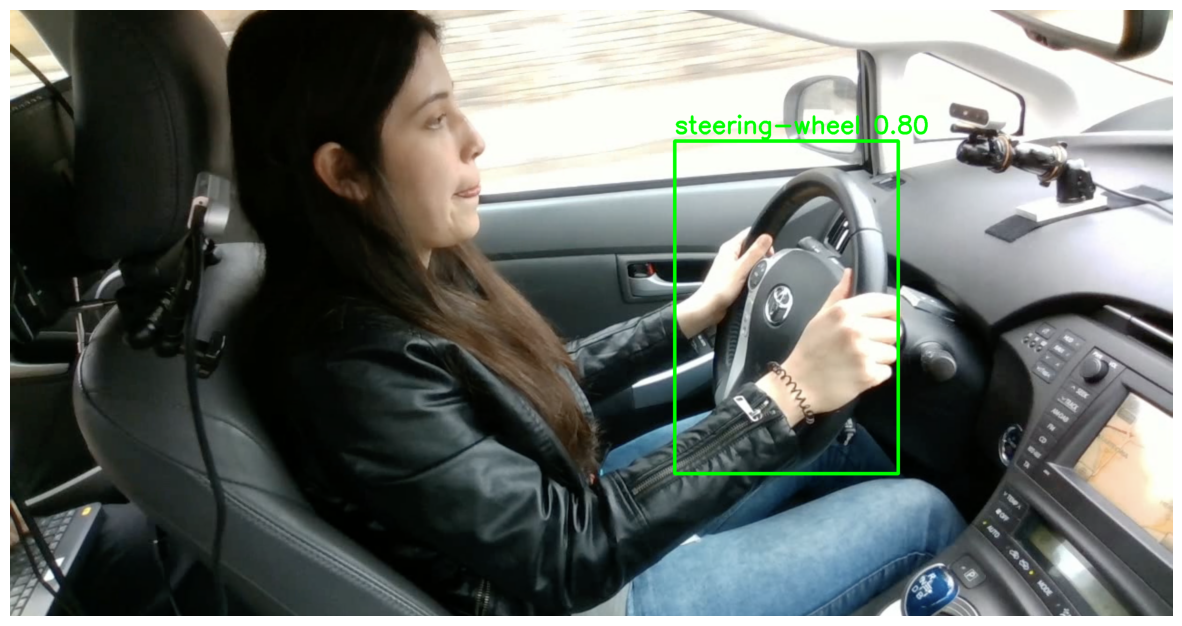

In [34]:
#PREDICTION STEERING WHEEL
start_time = time.time()
output = model.predict("test_img.png", confidence=40).json()
end_time = time.time()
print("Prediction Time:", end_time - start_time)
print(output)

image = cv2.imread("test_img.png")

for pred in output['predictions']:
    # Get center coordinates and dimensions
    x_center = pred['x']
    y_center = pred['y']
    w = pred['width']
    h = pred['height']

    # Convert to Top-Left and Bottom-Right corners
    x1 = int(x_center - (w / 2))
    y1 = int(y_center - (h / 2))
    x2 = int(x_center + (w / 2))
    y2 = int(y_center + (h / 2))

    # Draw the box
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 8) # Thicker line for high res
    
    # Label
    label = f"{pred['class']} {pred['confidence']:.2f}"
    cv2.putText(image, label, (x1, y1 - 20), 
                cv2.FONT_HERSHEY_SIMPLEX, 2.0, (0, 255, 0), 5)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 4. Display
plt.figure(figsize=(15, 10))
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

Hand & Pose Detection Time: 0.025783061981201172


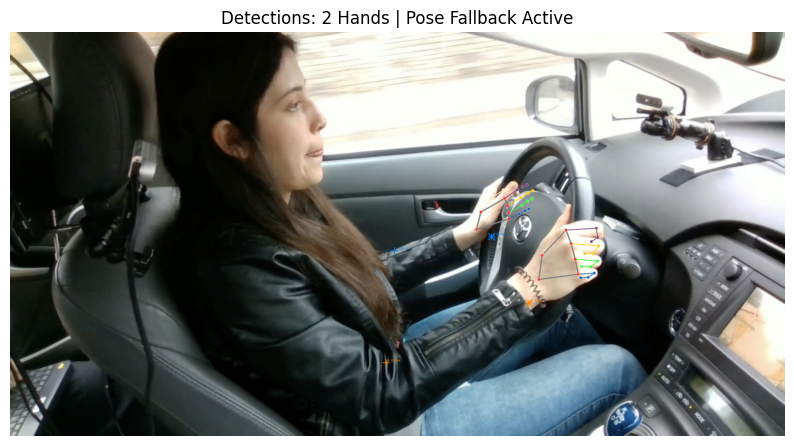

In [35]:
#PREDICTION HANDS AND POSE
img_path = "test_img.png"
mp_image = mp.Image.create_from_file(img_path)
rgb_frame = mp_image.numpy_view()
img_h, img_w = rgb_frame.shape[:2]


# Detect Hands and Pose (MediaPipe)
start_time = time.time()
hand_result = hand_detector.detect(mp_image)
pose_result = pose_detector.detect(mp_image)
end_time = time.time()
print("Hand & Pose Detection Time:", end_time - start_time)
annotated_image = draw_landmarks_on_image(rgb_frame, hand_result)
annotated_image = draw_pose_markers(annotated_image, pose_result, img_w, img_h)


plt.figure(figsize=(10, 10))
plt.imshow(annotated_image[:, :, ::-1]) # BGR to RGB
plt.axis('off')
plt.title(f"Detections: {len(hand_result.hand_landmarks)} Hands | Pose Fallback Active")
plt.show()

In [36]:
#HANDS ON WHEEL DETECTION
hands_on_wheel = False

# 1. Check Hand Landmarks (21 points per hand)
if hand_result.hand_landmarks:
    for hand_lms in hand_result.hand_landmarks:
        for lm in hand_lms:
            # MediaPipe landmarks are normalized (0.0 to 1.0)
            cx, cy = int(lm.x * img_w), int(lm.y * img_h)

            if x1 <= cx <= x2 and y1 <= cy <= y2:
                hands_on_wheel = True
                break

print("Hands on Wheel Detected:", hands_on_wheel)

Hands on Wheel Detected: True


Steering Detection Time: 1.7895958423614502
Hand result: HandLandmarkerResult(handedness=[[Category(index=0, score=0.9957467317581177, display_name='Right', category_name='Right')], [Category(index=0, score=0.6068407297134399, display_name='Right', category_name='Right')]], hand_landmarks=[[NormalizedLandmark(x=0.682589590549469, y=0.6133648157119751, z=-3.716666441277994e-08, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6864452958106995, y=0.5538874268531799, z=0.0027921325527131557, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7008271813392639, y=0.5019744038581848, z=-0.0014421537052839994, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7146288752555847, y=0.46192046999931335, z=-0.00593755766749382, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7216216921806335, y=0.4321814179420471, z=-0.009685374796390533, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7174199223518372, y=0.49

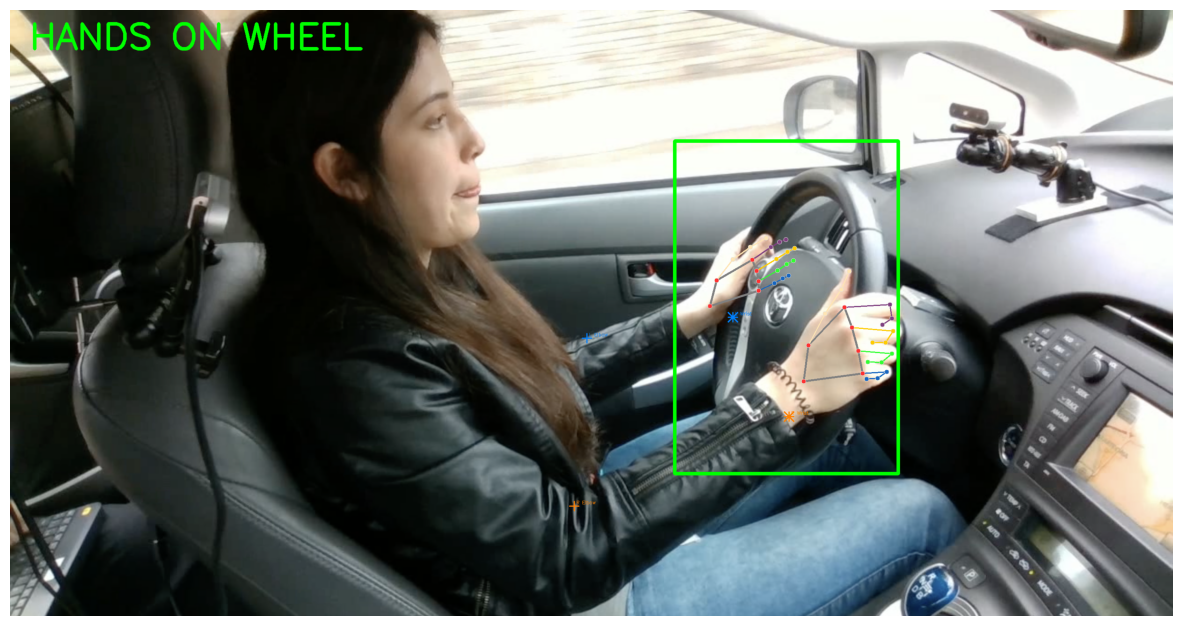

Detection Result: {'steering_box': (1680, 333, 2245, 1173), 'hands_on_wheel': True, 'hand_landmarks': [[NormalizedLandmark(x=0.682589590549469, y=0.6133648157119751, z=-3.716666441277994e-08, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6864452958106995, y=0.5538874268531799, z=0.0027921325527131557, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7008271813392639, y=0.5019744038581848, z=-0.0014421537052839994, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7146288752555847, y=0.46192046999931335, z=-0.00593755766749382, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7216216921806335, y=0.4321814179420471, z=-0.009685374796390533, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7174199223518372, y=0.49135822057724, z=-0.01595979742705822, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.756481945514679, y=0.48714640736579895, z=-0.019428515806794167, visibility=None, p

E0000 00:00:1777911527.839214 1430904 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-04T18:31:47.830971+02:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1777911527.847046 1430919 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-04T18:19:47.784343+02:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1777911538.670960 1389545 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-04T18:22:58.623767+02:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


In [ ]:
#Final Function:

def detect_steering_and_hands(image_path):
    # Load and preprocess image
    mp_image = mp.Image.create_from_file(image_path)
    rgb_frame = mp_image.numpy_view()
    img_h, img_w = rgb_frame.shape[:2]

    # 1. Detect Steering Wheel (YOLO)
    start_time = time.time()
    output = model.predict(image_path, confidence=40).json()
    end_time = time.time()
    print("Steering Detection Time:", end_time - start_time)

    steering_box = None
    if output['predictions']:
        pred = output['predictions'][0]  # Assuming one wheel per image
        x_center, y_center, w, h = pred['x'], pred['y'], pred['width'], pred['height']
        steering_box = (int(x_center - w/2), int(y_center - h/2), int(x_center + w/2), int(y_center + h/2))

    # 2. Detect Hands and Pose (MediaPipe)
    start_time = time.time()
    hand_result = hand_detector.detect(mp_image)
    print(f"Hand result: {hand_result}")
    pose_result = pose_detector.detect(mp_image)
    end_time = time.time()
    print("Hand & Pose Detection Time:", end_time - start_time)

    # 3. Check Hands on Wheel
    hands_on_wheel = False
    if steering_box and hand_result.hand_landmarks:
        x1, y1, x2, y2 = steering_box
        for hand_lms in hand_result.hand_landmarks:
            for lm in hand_lms:
                cx, cy = int(lm.x * img_w), int(lm.y * img_h)
                if x1 <= cx <= x2 and y1 <= cy <= y2:
                    hands_on_wheel = True
                    break
    annotated_image = draw_landmarks_on_image(rgb_frame, hand_result)
    annotated_image = draw_pose_markers(annotated_image, pose_result, img_w, img_h)

    # Draw Steering Wheel Box
    cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 8)

    # Add Status Text
    status_text = "HANDS ON WHEEL" if hands_on_wheel else "HANDS OFF WHEEL"
    status_color = (0, 255, 0) if hands_on_wheel else (0, 0, 255)
    cv2.putText(annotated_image, status_text, (50, 100), 
                cv2.FONT_HERSHEY_SIMPLEX, 3.0, status_color, 7)

    # Display final BGR to RGB
    plt.figure(figsize=(15, 10))
    plt.imshow(annotated_image[:, :, ::-1])
    plt.axis('off')
    plt.show()

    return {
        "steering_box": steering_box,
        "hands_on_wheel": hands_on_wheel,
        "hand_landmarks": hand_result.hand_landmarks,
        "pose_landmarks": pose_result.pose_landmarks
    }

detection_result = detect_steering_and_hands("test_img.png")
print("Detection Result:", detection_result)

Hand result: HandLandmarkerResult(handedness=[[Category(index=1, score=0.9806646108627319, display_name='Left', category_name='Left')]], hand_landmarks=[[NormalizedLandmark(x=0.6578623056411743, y=0.3176729083061218, z=1.6526948343198455e-07, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6775093674659729, y=0.3580942153930664, z=-0.022364245727658272, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.703527569770813, y=0.3640556037425995, z=-0.029027897864580154, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7297762036323547, y=0.3638504147529602, z=-0.030642272904515266, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7510356307029724, y=0.35970452427864075, z=-0.028912784531712532, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7220445871353149, y=0.27896395325660706, z=-0.018793359398841858, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7564640045166016, y=0.3183906

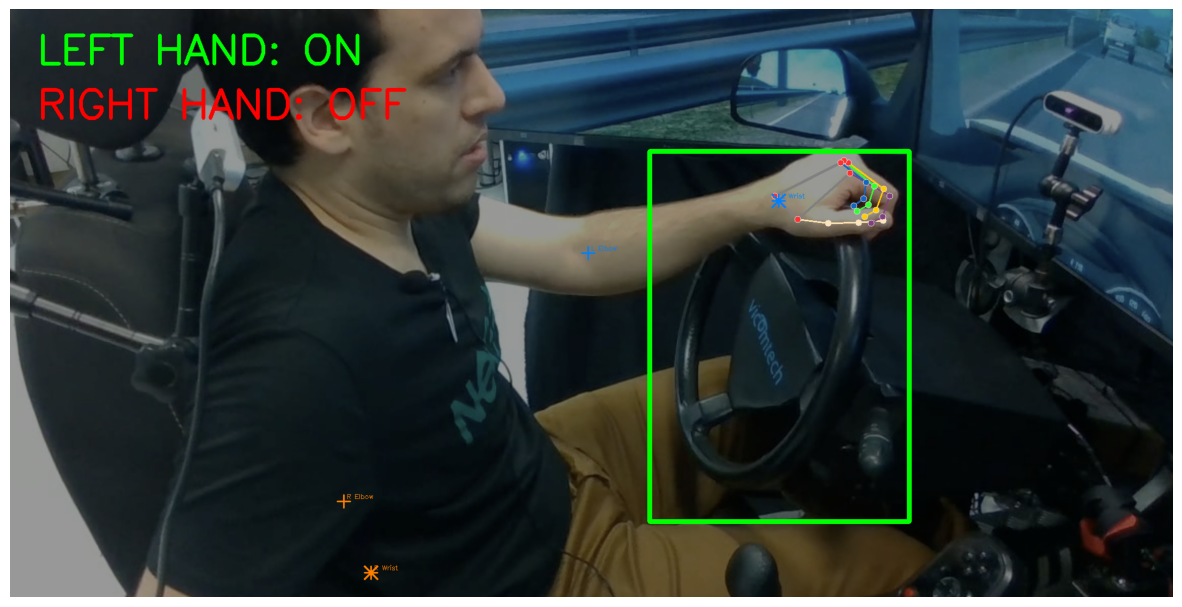

Detection Result: {'steering_box': (1175, 261, 1652, 941), 'left_hand_on': True, 'right_hand_on': False, 'hands_on_wheel': True}


E0000 00:00:1777912668.054922 1430904 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-04T18:46:48.030362+02:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1777912668.219293 1430919 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-04T18:49:48.204203+02:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


In [59]:
def detect_steering_and_hands(image_path):
    # Load and preprocess image
    mp_image = mp.Image.create_from_file(image_path)
    rgb_frame = mp_image.numpy_view()
    img_h, img_w = rgb_frame.shape[:2]

    # 1. Detect Steering Wheel (YOLO/Roboflow)
    output = model.predict(image_path, confidence=40).json()
    steering_box = None
    if output['predictions']:
        pred = output['predictions'][0]
        x_center, y_center, w, h = pred['x'], pred['y'], pred['width'], pred['height']
        x1, y1, x2, y2 = (int(x_center - w/2), int(y_center - h/2), 
                          int(x_center + w/2), int(y_center + h/2))
        steering_box = (x1, y1, x2, y2)

    # 2. Detect Hands and Pose (MediaPipe)
    hand_result = hand_detector.detect(mp_image)
    pose_result = pose_detector.detect(mp_image)
    print(f"Hand result: {hand_result}")
    detected_hands = []
    left_on = False
    right_on = False

    # Pre-process detections for logic checks
    if hand_result.hand_landmarks:
        for idx, hand_lms in enumerate(hand_result.hand_landmarks):
            score = hand_result.handedness[idx][0].score
            raw_label = hand_result.handedness[idx][0].category_name
            wrist_x = hand_lms[0].x * img_w
            wrist_y = hand_lms[0].y * img_h

            is_inside = False
            if steering_box:
                is_inside = any(x1 <= (lm.x * img_w) <= x2 and y1 <= (lm.y * img_h) <= y2 
                               for lm in hand_lms)

            detected_hands.append({
                "hand_lms": hand_lms,
                "raw_label": raw_label,
                "score": score,
                "wrist_y": wrist_y,
                "is_inside": is_inside
            })

    # 3. Custom Logic: Evaluate Left/Right Status
    if len(detected_hands) == 2:
        labels = [h["raw_label"] for h in detected_hands]
        scores = [h["score"] for h in detected_hands]

        if labels[0] != labels[1] and min(scores) > 0.75:
            # High confidence distinct labels -> apply mirroring fix (swap)
            for hand in detected_hands:
                hand["label"] = "Right" if hand["raw_label"] == "Right" else "Left"
        else:
            # Conflicting or low confidence -> use geometry (Vertical position on wheel)
            detected_hands.sort(key=lambda h: h["wrist_y"])
            detected_hands[0]["label"] = "Left"   # Physically higher in frame
            detected_hands[1]["label"] = "Right"  # Physically lower in frame

    elif len(detected_hands) == 1:
            hand = detected_hands[0]
            # Always flip the label (to fix the mirroring) 
            # but only apply the 'ON' status to that specific hand
            hand["label"] = "Right" if hand["raw_label"] == "Right" else "Left"
            
            # We explicitly ensure the OTHER hand is False
            if hand["label"] == "Left":
                left_on = hand["is_inside"]
                right_on = False
            else:
                right_on = hand["is_inside"]
                left_on = False

    # Final assignment based on processed labels
    for hand in detected_hands:
        if hand.get("is_inside") and "label" in hand:
            if hand["label"] == "Left": left_on = True
            elif hand["label"] == "Right": right_on = True

    # 4. Visualization
    annotated_image = draw_landmarks_on_image(rgb_frame, hand_result)
    annotated_image = draw_pose_markers(annotated_image, pose_result, img_w, img_h)

    if steering_box:
        cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 8)

    status_y = 100
    for side, is_on in [("LEFT", left_on), ("RIGHT", right_on)]:
        text = f"{side} HAND: {'ON' if is_on else 'OFF'}"
        color = (0, 255, 0) if is_on else (0, 0, 255)
        cv2.putText(annotated_image, text, (50, status_y), 
                    cv2.FONT_HERSHEY_SIMPLEX, 2.5, color, 6)
        status_y += 100

    plt.figure(figsize=(15, 10))
    plt.imshow(annotated_image[:, :, ::-1])
    plt.axis('off')
    plt.show()

    return {
        "steering_box": steering_box,
        "left_hand_on": left_on,
        "right_hand_on": right_on,
        "hands_on_wheel": left_on or right_on
    }

detection_result = detect_steering_and_hands("test_img2.png")
print("Detection Result:", detection_result)